In [2]:
import sys
import os.path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
from matplotlib.ticker import AutoMinorLocator
import uproot
import awkward as ak
import vector
import time
import requests
import pandas as pd

In [3]:
MeV = 0.001
GeV = 1.0

In [4]:
import atlasopenmagic as atom
atom.available_releases()
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 850.59datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [5]:
lumi = 36.6
fraction = 1.0
skim = "exactly4lep"
defs = {
    r'Data':{'dids':['data']},
    r'Background $Z,t\bar{t},t\bar{t}+V,VVV$':{'dids':[410470,410155,410218,
                                                        410219,412043,364243,
                                                        364242,364246,364248,
                                                        700320,700321,700322,
                                                        700323,700324,700325], 'color': "#2484bb" },
    r'Background $ZZ^{*}$':     {'dids': [700600],'color': "#3f21ac" },
    r'Signal ($m_H$ = 125 GeV)':  {'dids': [345060, 346228, 346310, 346311, 346312,
                                          346340, 346341, 346342],'color': "#0ed14f" },
}

samples   = atom.build_dataset(defs, skim=skim, protocol='https', cache=True)
data15_periodD = samples['Data']['list'][0]
tree = uproot.open(data15_periodD + ":analysis")
print(tree.keys())
variables = ['lep_pt','lep_eta','lep_phi','lep_e','lep_charge','lep_type','trigE','trigM','lep_isTrigMatched',
            'lep_isLooseID','lep_isMediumID','lep_isLooseIso','lep_type','jet_n','met','met_mpx','met_mpy']

['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'category', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'xsec', 'filteff', 'kfac', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMediumID', 'lep_isLooseID', 'lep_isTightIso', 'lep_isLooseIso', 'lep_isTrigMatched', 'ScaleFactor_PHOTON', 'photon_n'

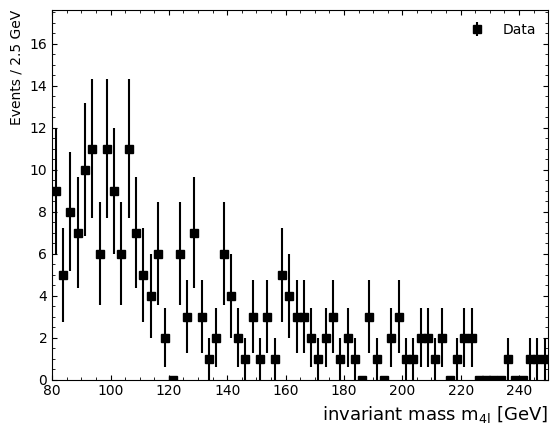

In [6]:
def cut_lep_type(lep_type):
    sum_lep_type = lep_type[:, 0] + lep_type[:, 1] + lep_type[:, 2] + lep_type[:, 3]
    lep_type_cut_bool = (sum_lep_type != 44) & (sum_lep_type != 48) & (sum_lep_type != 52)
    return lep_type_cut_bool

def cut_lep_charge(lep_charge):
    # first lepton in each event is [:, 0], 2nd lepton is [:, 1] etc
    sum_lep_charge = lep_charge[:, 0] + lep_charge[:, 1] + lep_charge[:, 2] + lep_charge[:, 3] != 0
    return sum_lep_charge

def calc_mass(lep_pt, lep_eta, lep_phi, lep_e):
    p4 = vector.zip({"pt": lep_pt, "eta": lep_eta, "phi": lep_phi, "E": lep_e})
    invariant_mass = (p4[:, 0] + p4[:, 1] + p4[:, 2] + p4[:, 3]).M # .M calculates the invariant mass
    return invariant_mass

def cut_trig_match(lep_trigmatch):
    trigmatch = lep_trigmatch
    cut1 = ak.sum(trigmatch, axis=1) >= 1
    return cut1

def cut_trig(trigE, trigM):
    return trigE | trigM

def ID_iso_cut(IDel,IDmu,isoel,isomu,pid):
    thispid = pid
    return (ak.sum(((thispid == 13) & IDmu & isomu) | ((thispid == 11) & IDel & isoel), axis=1) == 4)

sample_data = []
for data in tree.iterate(variables, library="ak"):
    lep_type = data['lep_type']
    data = data[~cut_lep_type(lep_type)]
    lep_charge = data['lep_charge']
    data = data[~cut_lep_charge(lep_charge)]
    data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])
    sample_data.append(data)

data_A = ak.concatenate(sample_data)

xmin = 80 * GeV
xmax = 250 * GeV
step_size = 2.5 * GeV
bin_edges = np.arange(start=xmin,
                    stop=xmax+step_size, 
                    step=step_size ) 
bin_centres = np.arange(start=xmin+step_size/2, 
                        stop=xmax+step_size/2,
                        step=step_size ) 

data_x,_ = np.histogram(ak.to_numpy(data_A['mass']),
                        bins=bin_edges ) 
data_x_errors = np.sqrt(data_x) 

main_axes = plt.gca() 
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ks', 
                    label='Data')

main_axes.set_xlim( left=xmin, right=xmax )
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )
main_axes.tick_params(which='both', 
                        direction='in', 
                        top=True,
                        right=True ) 

main_axes.set_xlabel(r'invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

main_axes.set_ylim( bottom=0, top=np.amax(data_x)*1.6 )
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )
main_axes.legend( frameon=False );

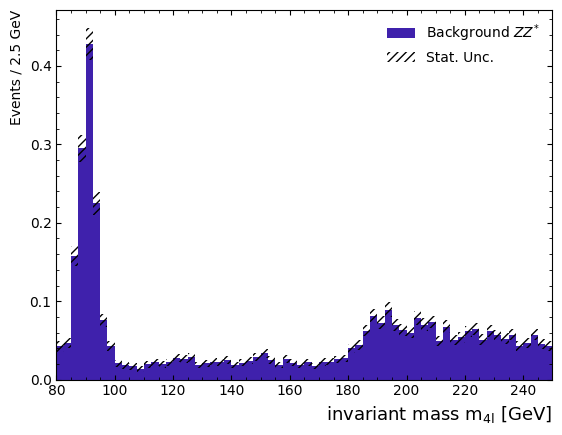

In [ ]:
value_tt = samples[r'Background $ZZ^{*}$']["list"][0] + ":analysis"
tree = uproot.open(value_tt) 
weight_variables = ["filteff","kfac","xsec","mcWeight","ScaleFactor_PILEUP", "ScaleFactor_ELE", "ScaleFactor_MUON", "ScaleFactor_LepTRIGGER"]
tree["ScaleFactor_MUON"].arrays(library = "ak")

lumi = 36.6
def calc_weight(weight_variables, events):
    total_weight = lumi * 1000 / events["sum_of_weights"]
    for variable in weight_variables:
        total_weight = total_weight * abs(events[variable])
    return total_weight

sample_data = []
for data in tree.iterate(variables + weight_variables+['sum_of_weights'], library="ak"):
    lep_type = data['lep_type']
    data = data[~cut_lep_type(lep_type)]
    lep_charge = data['lep_charge']
    data = data[~cut_lep_charge(lep_charge)]
    data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])
    data['totalWeight'] = calc_weight(weight_variables, data)
    sample_data.append(data)

background_ttbar = ak.concatenate(sample_data)

step_size = 2.5 * GeV

mc_x = ak.to_numpy(background_ttbar["mass"]) # define list to hold the Monte Carlo histogram entries
mc_weights = ak.to_numpy(background_ttbar["totalWeight"]) # define list to hold the Monte Carlo weights
mc_colors = samples[r'Background $ZZ^{*}$']['color'] # define list to hold the colors of the Monte Carlo bars
mc_labels = r'Background $ZZ^{*}$' # define list to hold the legend labels of the Monte Carlo bars

# *************
# Main plot
# *************
main_axes = plt.gca() # get current axes

# plot the data points
# main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
#                     fmt='ko', # 'k' means black and 'o' is for circles
#                     label='Data')

# plot the Monte Carlo bars
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels )

mc_x_tot = mc_heights[0] # stacked background MC y-axis value

# calculate MC statistical uncertainty: sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges, weights=np.hstack(mc_weights)**2)[0])

# plot the statistical uncertainty
main_axes.bar(bin_centres, # x
                2*mc_x_err, # heights
                alpha=0.5, # half transparency
                bottom=mc_x_tot-mc_x_err, color='none',
                hatch="////", width=step_size, label='Stat. Unc.' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
main_axes.legend( frameon=False ); # no box around the legend

In [ ]:
value_tt = samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']["list"][0] + ":analysis"
tree = uproot.open(value_tt) 
weight_variables = ["filteff","kfac","xsec","mcWeight","ScaleFactor_PILEUP", "ScaleFactor_ELE", "ScaleFactor_MUON", "ScaleFactor_LepTRIGGER"]
tree["ScaleFactor_MUON"].arrays(library = "ak")

lumi = 36.6
def calc_weight(weight_variables, events):
    total_weight = lumi * 1000 / events["sum_of_weights"]
    for variable in weight_variables:
        total_weight = total_weight * abs(events[variable])
    return total_weight

sample_data = []
for data in tree.iterate(variables + weight_variables+['sum_of_weights'], library="ak"):
    lep_type = data['lep_type']
    data = data[~cut_lep_type(lep_type)]
    lep_charge = data['lep_charge']
    data = data[~cut_lep_charge(lep_charge)]
    data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])
    data['totalWeight'] = calc_weight(weight_variables, data)
    sample_data.append(data)

background_ttbar = ak.concatenate(sample_data)

step_size = 2.5 * GeV

mc_x = ak.to_numpy(background_ttbar["mass"]) # define list to hold the Monte Carlo histogram entries
mc_weights = ak.to_numpy(background_ttbar["totalWeight"]) # define list to hold the Monte Carlo weights
mc_colors = samples[r'Background $Z,t\bar{t},t\bar{t}+V,VVV$']['color'] # define list to hold the colors of the Monte Carlo bars
mc_labels = r'Background $Z,t\bar{t},t\bar{t}+V,VVV$' # define list to hold the legend labels of the Monte Carlo bars

# *************
# Main plot
# *************
main_axes = plt.gca() # get current axes

# plot the data points
# main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
#                     fmt='ko', # 'k' means black and 'o' is for circles
#                     label='Data')

# plot the Monte Carlo bars
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels )

mc_x_tot = mc_heights[0] # stacked background MC y-axis value

# calculate MC statistical uncertainty: sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges, weights=np.hstack(mc_weights)**2)[0])

# plot the statistical uncertainty
main_axes.bar(bin_centres, # x
                2*mc_x_err, # heights
                alpha=0.5, # half transparency
                bottom=mc_x_tot-mc_x_err, color='none',
                hatch="////", width=step_size, label='Stat. Unc.' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'4-lepton invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# draw the legend
main_axes.legend( frameon=False ); # no box around the legend

TypeError: 'ClientResponseError' object is not subscriptable

In [9]:
lumi = 36.6

# Controls the fraction of all events analysed
fraction = 1.0 # reduce this is if you want quicker runtime (implemented in the loop over the tree)

# Define empty dictionary to hold awkward arrays
all_data = {}

# Loop over samples
for s in samples:

    # Print which sample is being processed
    print('Processing '+s+' samples')

    # Define empty list to hold data
    frames = []

    # Loop over each file
    for val in samples[s]['list']:
        if s == 'data':
            prefix = "Data/" # Data prefix
        else: # MC prefix
            prefix = "MC/mc_"
        fileString = val.replace("simplecache::", "")

        # start the clock
        start = time.time()
        print("\t"+val+":")

        # Open file
        file_name = os.path.basename(fileString)
        local_path = os.path.join(r"C:\Users\Cucuruz\Downloads\H2ZZ", file_name)
        if not os.path.exists(local_path):
            with requests.get(fileString, stream=True) as r:
                r.raise_for_status()
                with open(local_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024*1024):
                        f.write(chunk)

        tree = uproot.open(local_path)['analysis']

        sample_data = []

        # Loop over data in the tree
        for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n"],
                                 library="ak",
                                 entry_stop=tree.num_entries*fraction,#, # process up to numevents*fraction
                                 step_size = 10000000):

            # Number of events in this batch
            nIn = len(data)

            data = data[cut_trig(data.trigE, data.trigM)]
            data = data[cut_trig_match(data.lep_isTrigMatched)]

            # Record transverse momenta (see bonus activity for explanation)
            data['leading_lep_pt'] = data['lep_pt'][:,0]
            data['sub_leading_lep_pt'] = data['lep_pt'][:,1]
            data['third_leading_lep_pt'] = data['lep_pt'][:,2]
            data['last_lep_pt'] = data['lep_pt'][:,3]

            # Cuts on transverse momentum
            data = data[data['leading_lep_pt'] > 40]
            data = data[data['sub_leading_lep_pt'] > 30]
            data = data[data['third_leading_lep_pt'] > 10]

            data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]

            # Number Cuts
            #data = data[data['lep_n'] == 4]

            # Lepton cuts

            lep_type = data['lep_type']
            data = data[~cut_lep_type(lep_type)]
            lep_charge = data['lep_charge']
            data = data[~cut_lep_charge(lep_charge)]

            # Invariant Mass
            data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])

            # Store Monte Carlo weights in the data
            if 'data' not in s: # Only calculates weights if the data is MC
                data['totalWeight'] = calc_weight(weight_variables, data)
                # data['totalWeight'] = calc_weight(data)

            # Append data to the whole sample data list
            sample_data.append(data)

            if not 'data' in val:
                nOut = sum(data['totalWeight']) # sum of weights passing cuts in this batch
            else:
                nOut = len(data)

            elapsed = time.time() - start # time taken to process
            print("\t\t nIn: "+str(nIn)+",\t nOut: \t"+str(nOut)+"\t in "+str(round(elapsed,1))+"s") # events before and after

        frames.append(ak.concatenate(sample_data))

    all_data[s] = ak.concatenate(frames) # dictionary entry is concatenated awkward arrays

data_x,_ = np.histogram(ak.to_numpy(all_data['Data']['mass']),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

signal_x = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['mass']) # histogram the signal
signal_weights = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)'].totalWeight) # get the weights of the signal events
signal_color = samples[r'Signal ($m_H$ = 125 GeV)']['color'] # get the colour for the signal bar

mc_x = [] # define list to hold the Monte Carlo histogram entries
mc_weights = [] # define list to hold the Monte Carlo weights
mc_colors = [] # define list to hold the colors of the Monte Carlo bars
mc_labels = [] # define list to hold the legend labels of the Monte Carlo bars

for s in samples: # loop over samples
    if s not in ['Data', r'Signal ($m_H$ = 125 GeV)']: # if not data nor signal
        mc_x.append( ak.to_numpy(all_data[s]['mass']) ) # append to the list of Monte Carlo histogram entries
        mc_weights.append( ak.to_numpy(all_data[s].totalWeight) ) # append to the list of Monte Carlo weights
        mc_colors.append( samples[s]['color'] ) # append to the list of Monte Carlo bar colors
        mc_labels.append( s ) # append to the list of Monte Carlo legend labels

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
		 nIn: 3424,	 nOut: 	2	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
		 nIn: 25092,	 nOut: 	8	 in 0.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
		 nIn: 16234,	 nOut: 	5	 in 0.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
		 nIn: 37101,	 nOut: 	10	 in 1.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
		 nIn: 12152,	 nOut: 	3	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
		

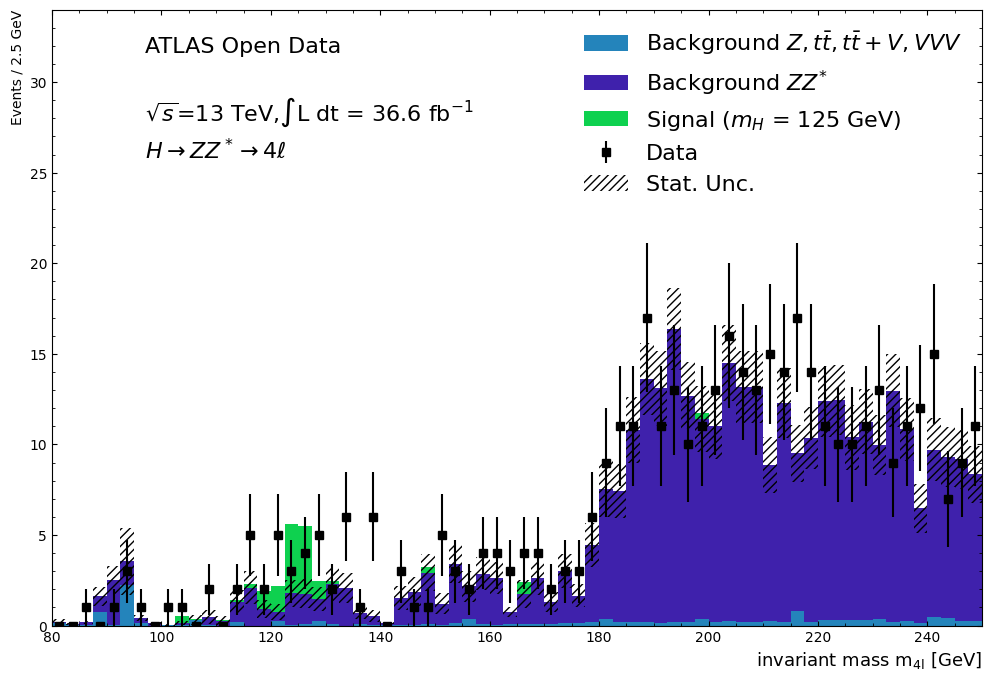

In [10]:
fig, main_axes = plt.subplots(figsize=(12, 8))

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ks', # 'k' means black and 'o' is for circles
                    label='Data')

# plot the Monte Carlo bars
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels )

mc_x_tot = mc_heights[0][-1] # stacked background MC y-axis value

# calculate MC statistical uncertainty: sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges, weights=np.hstack(mc_weights)**2)[0])

# plot the signal bar
signal_heights = main_axes.hist(signal_x, bins=bin_edges, bottom=mc_x_tot,
                weights=signal_weights, color=signal_color,
                label=r'Signal ($m_H$ = 125 GeV)')

# plot the statistical uncertainty
main_axes.bar(bin_centres, # x
                2*mc_x_err, # heights
                alpha=0.5, # half transparency
                bottom=mc_x_tot-mc_x_err, color='none',
                hatch="////", width=step_size, label='Stat. Unc.' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*2.0 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# Add text 'ATLAS Open Data' on plot

plt.text(0.1, # x
            0.93, # y
            'ATLAS Open Data', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            fontsize=16 )
"""
plt.text(0.1, # x
            0.88, # y
            'for education', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            style='italic',
            fontsize=12 )
""" 

# Add energy and luminosity
lumi_used = str(lumi*fraction) # luminosity to write on the plot
plt.text(0.1, # x
            0.82, # y
            r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+' fb$^{-1}$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# Add a label for the analysis carried out
plt.text(0.1, # x
            0.76, # y
            r'$H \rightarrow ZZ^* \rightarrow 4\ell$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# draw the legend
my_legend = main_axes.legend( frameon=False, fontsize=16 )

In [11]:
signal_tot = signal_heights[0] + mc_x_tot
N_sig = signal_tot[17:20].sum()
N_bg = mc_x_tot[17:20].sum()
signal_significance = N_sig/np.sqrt(N_bg + 0.25 * N_bg**2)
asimov_significance = np.sqrt(2*((N_sig+N_bg)*np.log(1+N_sig/N_bg)-N_sig))
N = N_sig + N_bg
relative_significance = np.sqrt(N)/N
print("relError=", relative_significance)
print("S/B=", signal_significance)
print("S/B=", asimov_significance)

relError= 0.23208029037378491
S/B= 4.026784054349657
S/B= 4.634343680823126


In [12]:
def calc_lep_pt_i(lep_pt):
    return lep_pt/1000

def get_data_from_files():

    all_data = {}
    for s in samples:

        print('Processing '+s+' samples')

        frames = []

        for val in samples[s]['list']:
            if s == 'data':
                prefix = "Data/" # Data prefix
            else: # MC prefix
                prefix = "MC/mc_"
            fileString = val.replace("simplecache::", "")

            start = time.time()
            print("\t"+val+":")

            file_name = os.path.basename(fileString)
            local_path = os.path.join(r"C:\Users\Cucuruz\Downloads\H2ZZ", file_name)
            if not os.path.exists(local_path):
                with requests.get(fileString, stream=True) as r:
                    r.raise_for_status()
                    with open(local_path, "wb") as f:
                        for chunk in r.iter_content(chunk_size=1024*1024):
                            f.write(chunk)

            tree = uproot.open(local_path)['analysis']

            sample_data = []

            for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n"],
                                 library="ak",
                                 entry_stop=tree.num_entries*fraction,#, # process up to numevents*fraction
                                 step_size = 10000000):


                if 'data' not in s: 
                    data['totalWeight'] = calc_weight(weight_variables, data)
                else:
                    data['totalWeight'] = 1

                lep_type = data['lep_type']
                data = data[~cut_lep_type(lep_type)]
                lep_charge = data['lep_charge']
                data = data[~cut_lep_charge(lep_charge)]

                """
                data = data[cut_trig(data.trigE, data.trigM)]
                data = data[cut_trig_match(data.lep_isTrigMatched)]
                data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]
                """
                
                lep_mass = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
                #data = data[(lep_mass > 115) & (lep_mass < 130)]

                data['lep_pt_1'] = data['lep_pt'][:,0]
                data['lep_pt_2'] = data['lep_pt'][:,1]
                data['lep_pt_3'] = data['lep_pt'][:,2]
                data['lep_pt_4'] = data['lep_pt'][:,3]
                data['lep_eta_1'] = data['lep_eta'][:,0]
                data['lep_eta_2'] = data['lep_eta'][:,1]
                data['lep_eta_3'] = data['lep_eta'][:,2]
                data['lep_eta_4'] = data['lep_eta'][:,3]

                """
                delta_phi = (data['lep_phi_1']-data['lep_phi_2'])
                delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
                data['iso_angle_1'] = np.sqrt((data['lep_eta_1']-data['lep_eta_2'])**2+delta_phi**2)
                delta_phi = (data['lep_phi_3']-data['lep_phi_4'])
                delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
                data['iso_angle_2'] = np.sqrt((data['lep_eta_3']-data['lep_eta_4'])**2+delta_phi**2)
                """
                
                data['met_pt'] = np.sqrt(data['met_mpx']**2+data['met_mpy']**2)
                data['lep_mass'] = lep_mass

                sample_data.append(data)
            elapsed = time.time() - start # time taken to process
            print("in "+str(round(elapsed,1))+"s") 
            frames.append(ak.concatenate(sample_data))

        all_data[s] = ak.concatenate(frames)
    
    return all_data

start = time.time() 
data = get_data_from_files() 
elapsed = time.time() - start 
print("Time taken: "+str(round(elapsed,1))+"s")

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
in 1.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
in 1.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
in 2.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4

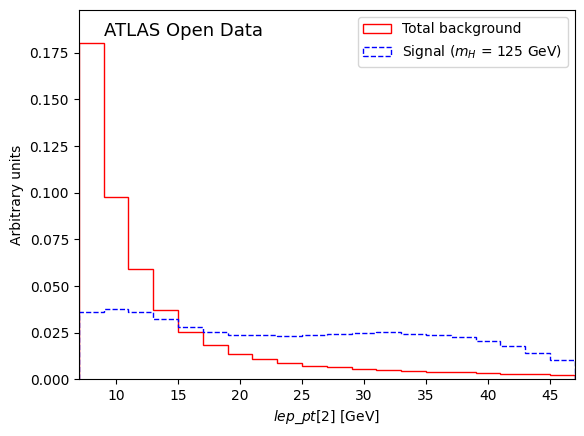

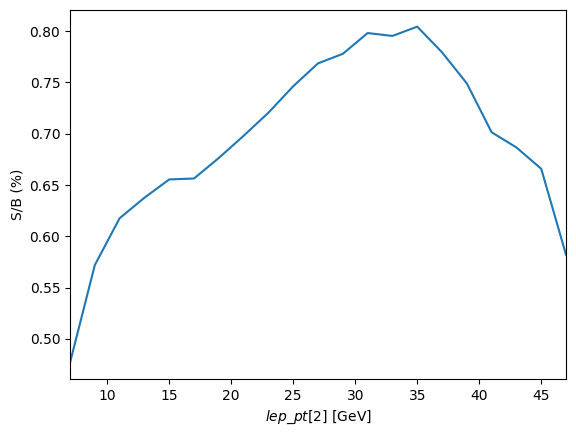

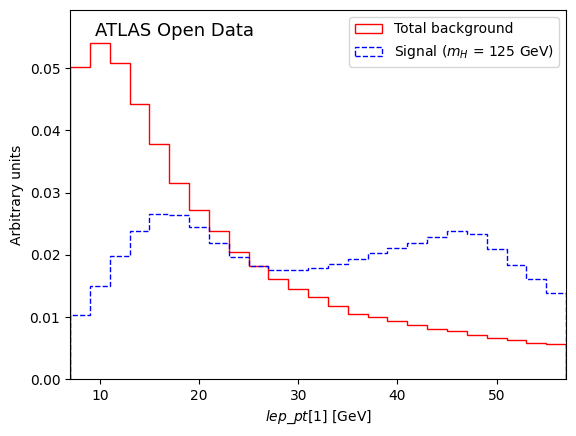

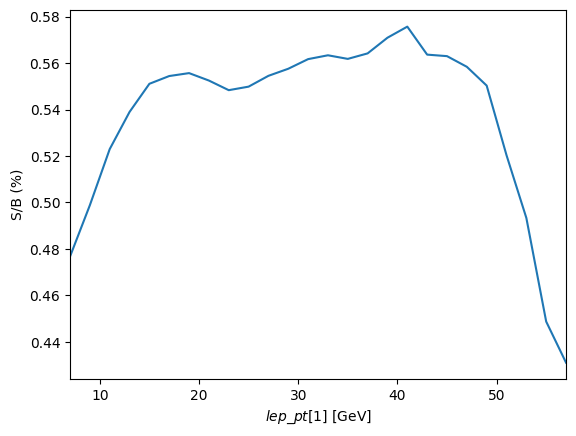

In [13]:
lep_pt_2 = { # dictionary containing plotting parameters for the lep_pt_2 histogram
    # change plotting parameters
    'bin_width':2, # width of each histogram bin
    'num_bins':20, # number of histogram bins
    'xrange_min':7, # minimum on x-axis
    'xlabel':r'$lep\_pt$[2] [GeV]', # x-axis label
}

lep_pt_1 = { # dictionary containing plotting parameters for the lep_pt_1 histogram
    # change plotting parameters
    'bin_width':2, # width of each histogram bin
    'num_bins':25, # number of histogram bins
    'xrange_min':7, # minimum on x-axis
    'xlabel':r'$lep\_pt$[1] [GeV]', # x-axis label
}

SoverB_hist_dict = {'lep_pt_2':lep_pt_2,'lep_pt_1':lep_pt_1} 

def plot_SoverB(data):
    
    signal = r'Signal ($m_H$ = 125 GeV)' # which sample is the signal

    # *******************
    # general definitions (shouldn't need to change)

    for x_variable,hist in SoverB_hist_dict.items(): # access the dictionary of histograms defined in the cell above

        h_bin_width = hist['bin_width'] # get the bin width defined in the cell above
        h_num_bins = hist['num_bins'] # get the number of bins defined in the cell above
        h_xrange_min = hist['xrange_min'] # get the x-range minimum defined in the cell above
        h_xlabel = hist['xlabel'] # get the x-axis label defined in the cell above
    
        bin_edges = [ h_xrange_min + x*h_bin_width for x in range(h_num_bins+1) ] # bin limits
        bin_centres = [ h_xrange_min+h_bin_width/2 + x*h_bin_width for x in range(h_num_bins) ] # bin centres
        
        signal_x = data[signal][x_variable] # histogram the signal
    
        mc_x = [] # define list to hold the Monte Carlo histogram entries

        for s in samples: # loop over samples
            if s not in ['data', signal]: # if not data nor signal
                mc_x = [*mc_x, *data[s][x_variable] ] # append to the list of Monte Carlo histogram entries

    
    
        # *************
        # Signal and background distributions
        # *************
        distributions_axes = plt.gca() # get current axes
 
        mc_heights = distributions_axes.hist(mc_x, bins=bin_edges, color='red', 
                                             label='Total background',
                                             histtype='step', # lineplot that's unfilled
                                             density=True ) # normalize to form probability density
        signal_heights = distributions_axes.hist(signal_x, bins=bin_edges, color='blue',
                                                 label=signal, 
                                                 histtype='step', # lineplot that's unfilled
                                                 density=True, # normalize to form probability density
                                                 linestyle='--' ) # dashed line
        
        distributions_axes.set_xlim( left=bin_edges[0], right=bin_edges[-1] ) # x-limits of the distributions axes
        distributions_axes.set_ylabel('Arbitrary units' ) # y-axis label for distributions axes
        distributions_axes.set_ylim( top=max(mc_heights[0])*1.1 ) # set y-axis limits
        distributions_axes.legend() # draw the legend
        distributions_axes.set_xlabel( h_xlabel ) # x-axis label
        
        # Add text 'ATLAS Open Data' on plot
        plt.text(0.05, # x
                 0.93, # y
                 'ATLAS Open Data', # text
                 transform=distributions_axes.transAxes, # coordinate system used is that of distributions_axes
                 fontsize=13 ) 
        # Add text 'for education' on plot
    
        plt.show() # show the Signal and background distributions
    
    
        # *************
        # Signal to background ratio
        # *************
        plt.figure() # start new figure
        SoverB = [] # list to hold S/B values
        for cut_value in bin_edges: # loop over bins
            signal_weights_passing_cut = sum(data[signal][data[signal][x_variable]>cut_value].totalWeight)
            background_weights_passing_cut = 0 # start counter for background weights passing cut
            for s in samples: # loop over samples
                if s not in ['data', signal]: # if not data nor signal
                    background_weights_passing_cut += sum(data[s][data[s][x_variable]>cut_value].totalWeight)
            if background_weights_passing_cut!=0: # some background passes cut
                SoverB_value = signal_weights_passing_cut/background_weights_passing_cut # multiply by 100 for percentage
                SoverB.append(SoverB_value*100) # append to list of S/B values
        
        SoverB_axes = plt.gca() # get current axes
        SoverB_axes.plot( bin_edges[:len(SoverB)], SoverB ) # plot the data points
        SoverB_axes.set_xlim( left=bin_edges[0], right=bin_edges[-1] ) # set the x-limit of the main axes
        SoverB_axes.set_ylabel( 'S/B (%)' ) # write y-axis label for main axes
        SoverB_axes.set_xlabel( h_xlabel ) # x-axis label 
        
        plt.show() # show S/B plot
    
    return

plot_SoverB(data)

In [14]:
import joblib
data_for_BDT = {} # define empty dictionary to hold dataframes that will be used to train the BDT
data = get_data_from_files() 
BDT_inputs = ['lep_pt_1','lep_pt_2','lep_pt_3','lep_pt_4','lep_eta_1','lep_eta_2','lep_eta_3','lep_eta_4','jet_n', 'met_pt'] # list of features for BDT
for key in data: # loop over the different keys in the dictionary of dataframes
    data_for_BDT[key] = data[key][BDT_inputs]

all_MC = [] # define empty list that will contain all features for the MC
for key in data: 
    if key!='data': 
        all_MC.append(data_for_BDT[key]) # append the MC dataframe to the list containing all MC features
X = np.concatenate(all_MC) # concatenate the list of MC dataframes into a single 2D array of features, called X

all_y = [] # define empty list that will contain labels whether an event in signal or background
for key in data: # loop over the different keys in the dictionary of dataframes
    if key!=r'Signal ($m_H$ = 125 GeV)' and key!='data': # only background MC should pass this
        all_y.append(np.zeros(len(data_for_BDT[key]))) # background events are labelled with 0
all_y.append(np.ones(len(data_for_BDT[r'Signal ($m_H$ = 125 GeV)']))) # signal events are labelled with 1
y = np.concatenate(all_y) 

from sklearn.model_selection import train_test_split

# make train and test sets
X_train,X_test, y_train,y_test = train_test_split(X, y, 
                                                  test_size=0.33, 
                                                  random_state=492 )

X_train = ak.to_dataframe(X_train)
y_train = ak.to_numpy(y_train)

X_test = ak.to_dataframe(X_test)
y_test = ak.to_numpy(y_test)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

"""
dt = DecisionTreeClassifier(max_depth=5) # maximum depth of the tree
bdt = AdaBoostClassifier(dt, # SAMME discrete boosting algorithm
                        n_estimators=1000, # max number of estimators at which boosting is terminated
                        learning_rate=0.05) # shrinks the contribution of each classifier by learning_rate

start = time.time() # time at start of BDT fit
bdt.fit(X_train, y_train) # fit BDT to training set
elapsed = time.time() - start # time after fitting BDT
print("Time taken to fit BDT: "+str(round(elapsed,1))+"s") # print total time taken to fit BDT
""" 
bdt = joblib.load('bdt_model_09535.pkl')
print(bdt)




Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
in 0.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
in 2.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
in 2.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4

              precision    recall  f1-score   support

  background       0.89      0.85      0.87    177948
      signal       0.85      0.88      0.87    167064

    accuracy                           0.87    345012
   macro avg       0.87      0.87      0.87    345012
weighted avg       0.87      0.87      0.87    345012

Area under ROC curve for test data: 0.9415


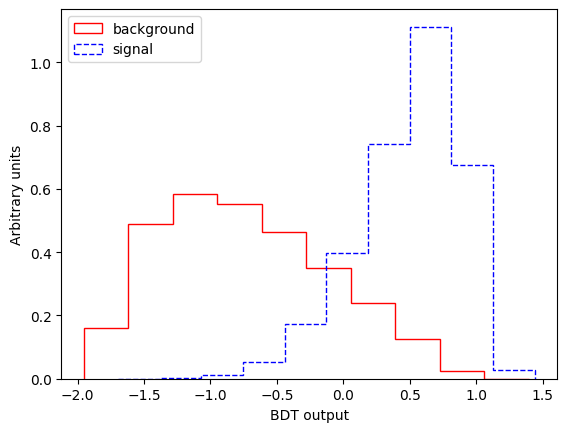

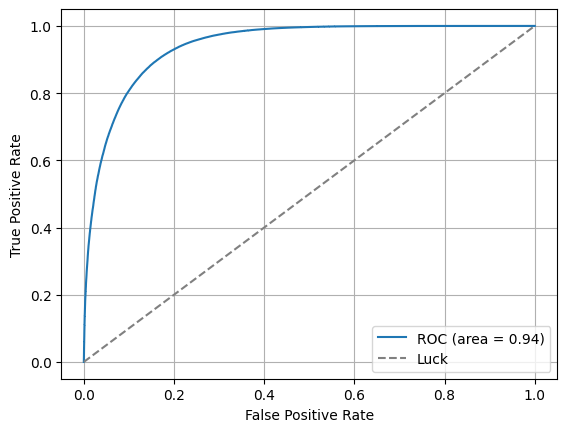

In [15]:
from sklearn.metrics import classification_report, roc_auc_score
y_predicted = bdt.predict(X_test) # get predicted y for test set
X = ak.to_dataframe(X)

print (classification_report(y_test, y_predicted,
                            target_names=["background", "signal"]))
print ("Area under ROC curve for test data: %.4f"%(roc_auc_score(y_test,
                                                    bdt.decision_function(X_test))) )

signal_decisions = bdt.decision_function(X[y>0.5]).ravel() # get probabilities on signal
background_decisions = bdt.decision_function(X[y<0.5]).ravel() # get decisions on background

plt.hist(background_decisions, color='red', label='background', 
         histtype='step', # lineplot that's unfilled
         density=True ) # normalize to form a probability density
plt.hist(signal_decisions, color='blue', label='signal', 
         histtype='step', # lineplot that's unfilled
         density=True, # normalize to form a probability density
         linestyle='--' ) # dashed line
plt.xlabel('BDT output') # add x-axis label
plt.ylabel('Arbitrary units') # add y-axis label
plt.legend() # add legend


# we then plot the ROC
plt.figure() # make new figure 

from sklearn.metrics import roc_curve, auc

decisions = bdt.decision_function(X_test).ravel() # get probabilities on test set

# Compute ROC curve and area under the curve
fpr, tpr, _ = roc_curve(y_test, # actual
                        decisions ) # predicted

# Compute area under the curve for training set
roc_auc = auc(fpr, # false positive rate 
              tpr) # true positive rate

plt.plot(fpr, tpr, label='ROC (area = %0.2f)'%(roc_auc)) # plot test ROC curve
plt.plot([0, 1], # x from 0 to 1
         [0, 1], # y from 0 to 1
         '--', # dashed line
         color='grey', label='Luck')

plt.xlabel('False Positive Rate') # x-axis label
plt.ylabel('True Positive Rate') # y-axis label
plt.legend() # add legend
plt.grid() # add grid

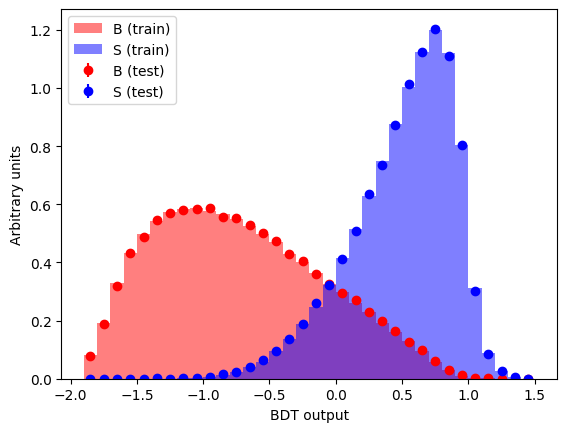

In [16]:
def compare_train_test(clf, X_train, y_train, X_test, y_test):
    decisions = [] # list to hold decisions of classifier
    for X,y in ((X_train, y_train), (X_test, y_test)): # train and test
        d1 = clf.decision_function(X[y<0.5]).ravel() # background
        d2 = clf.decision_function(X[y>0.5]).ravel() # signal
        decisions += [d1, d2] # add to list of classifier decision
    
    highest_decision = max(np.max(d) for d in decisions) # get maximum score
    bin_edges = [] # list to hold bin edges
    bin_edge = -2 # start counter for bin_edges
    while bin_edge < highest_decision: # up to highest score
        bin_edge += 0.1 # increment
        bin_edges.append(bin_edge)
    
    plt.hist(decisions[0], # background in train set
             bins=bin_edges, # lower and upper range of the bins
             density=True, # area under the histogram will sum to 1
             histtype='stepfilled', # lineplot that's filled
             color='red', label='B (train)', # Background (train)
            alpha=0.5 ) # half transparency
    plt.hist(decisions[1], # background in train set
             bins=bin_edges, # lower and upper range of the bins
             density=True, # area under the histogram will sum to 1
             histtype='stepfilled', # lineplot that's filled
             color='blue', label='S (train)', # Signal (train)
            alpha=0.5 ) # half transparency

    hist_background, bin_edges = np.histogram(decisions[2], # background test
                                              bins=bin_edges, # number of bins in function definition
                                              density=True ) # area under the histogram will sum to 1
    
    scale = len(decisions[2]) / sum(hist_background) # between raw and normalised
    err_background = np.sqrt(hist_background * scale) / scale # error on test background

    width = 0.1 # histogram bin width
    center = (bin_edges[:-1] + bin_edges[1:]) / 2 # bin centres
    
    plt.errorbar(x=center, y=hist_background, yerr=err_background, fmt='o', # circles
                 c='red', label='B (test)' ) # Background (test)
    
    hist_signal, bin_edges = np.histogram(decisions[3], # siganl test
                                          bins=bin_edges, # number of bins in function definition
                                          density=True ) # area under the histogram will sum to 1
    scale = len(decisions[3]) / sum(hist_signal) # between raw and normalised
    err_signal = np.sqrt(hist_signal * scale) / scale # error on test background
    
    plt.errorbar(x=center, y=hist_signal, yerr=err_signal, fmt='o', # circles
                 c='blue', label='S (test)' ) # Signal (test)
    
    plt.xlabel("BDT output") # write x-axis label
    plt.ylabel("Arbitrary units") # write y-axis label
    plt.legend() # add legend
    
compare_train_test(bdt, X_train, y_train, X_test, y_test) # call compare_train_test

In [17]:
cumulative_events = 0 
y_predicted = bdt.decision_function(X)
for key in data: # loop over samples
    data[key]['BDT_output'] = y_predicted[cumulative_events:cumulative_events+len(data[key])]
    cumulative_events += len(data[key]) # increment counter for total number of events
    print(data[key]['BDT_output']) # print the dataframe column BDT_output

BDT_output = { # dictionary containing plotting parameters for the mllll histogram
    # change plotting parameters
    'bin_width':0.2, # width of each histogram bin
    'num_bins':18, # number of histogram bins
    'xrange_min':-2.0, # minimum on x-axis
    'xlabel':'BDT output', # x-axis label
}

SoverB_hist_dict = {'BDT_output':BDT_output}
plot_SoverB(data)


KeyboardInterrupt: 

In [ ]:
importances = bdt.feature_importances_
std = np.std([tree.feature_importances_ for tree in bdt.estimators_], axis=0)

# 2. Sort them from highest to lowest
indices = np.argsort(importances)[::-1]
feature_names = np.array(BDT_inputs)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color="blue")
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel("Relative Importance Score")
plt.gca().invert_yaxis()  # Put the most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'bdt' is not defined

In [ ]:
lumi = 36.6

# Controls the fraction of all events analysed
fraction = 1.0 # reduce this is if you want quicker runtime (implemented in the loop over the tree)

# Define empty dictionary to hold awkward arrays
all_data = {}

# Loop over samples
for s in samples:

    # Print which sample is being processed
    print('Processing '+s+' samples')

    # Define empty list to hold data
    frames = []

    # Loop over each file
    for val in samples[s]['list']:
        if s == 'data':
            prefix = "Data/" # Data prefix
        else: # MC prefix
            prefix = "MC/mc_"
        fileString = val.replace("simplecache::", "")

        # start the clock
        start = time.time()
        print("\t"+val+":")

        # Open file
        file_name = os.path.basename(fileString)
        local_path = os.path.join(r"C:\Users\Cucuruz\Downloads\H2ZZ", file_name)
        if not os.path.exists(local_path):
            with requests.get(fileString, stream=True) as r:
                r.raise_for_status()
                with open(local_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024*1024):
                        f.write(chunk)

        tree = uproot.open(local_path)['analysis']

        sample_data = []

        # Loop over data in the tree
        for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n"],
                                 library="ak",
                                 entry_stop=tree.num_entries*fraction,#, # process up to numevents*fraction
                                 step_size = 10000000):

            # Number of events in this batch
            nIn = len(data)
            
            #data = data[data['lep_n'] == 4]
            data = data[cut_trig(data.trigE, data.trigM)]
            data = data[cut_trig_match(data.lep_isTrigMatched)]
            
            lep_type = data['lep_type']
            data = data[~cut_lep_type(lep_type)]
            lep_charge = data['lep_charge']
            data = data[~cut_lep_charge(lep_charge)]
            
            data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]
            
            lep_mass = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
                #data = data[(lep_mass > 115) & (lep_mass < 130)]

            data['lep_pt_1'] = data['lep_pt'][:,0]
            data['lep_pt_2'] = data['lep_pt'][:,1]
            data['lep_pt_3'] = data['lep_pt'][:,2]
            data['lep_pt_4'] = data['lep_pt'][:,3]
            data['lep_eta_1'] = data['lep_eta'][:,0]
            data['lep_eta_2'] = data['lep_eta'][:,1]
            data['lep_eta_3'] = data['lep_eta'][:,2]
            data['lep_eta_4'] = data['lep_eta'][:,3]

            """
            delta_phi = (data['lep_phi_1']-data['lep_phi_2'])
            delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
            data['iso_angle_1'] = np.sqrt((data['lep_eta_1']-data['lep_eta_2'])**2+delta_phi**2)
            delta_phi = (data['lep_phi_3']-data['lep_phi_4'])
            delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
            data['iso_angle_2'] = np.sqrt((data['lep_eta_3']-data['lep_eta_4'])**2+delta_phi**2)
            """
                
            data['met_pt'] = np.sqrt(data['met_mpx']**2+data['met_mpy']**2)
            data['lep_mass'] = lep_mass
            
            X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
            data = data[bdt.decision_function(X_batch) >= 0.5]

            # Invariant Mass
            data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])

            # Store Monte Carlo weights in the data
            if 'data' not in s: # Only calculates weights if the data is MC
                data['totalWeight'] = calc_weight(weight_variables, data)
                # data['totalWeight'] = calc_weight(data)

            # Append data to the whole sample data list
            sample_data.append(data)

            if not 'data' in val:
                nOut = sum(data['totalWeight']) # sum of weights passing cuts in this batch
            else:
                nOut = len(data)

            elapsed = time.time() - start # time taken to process
            print("\t\t nIn: "+str(nIn)+",\t nOut: \t"+str(nOut)+"\t in "+str(round(elapsed,1))+"s") # events before and after

        frames.append(ak.concatenate(sample_data))

    all_data[s] = ak.concatenate(frames) # dictionary entry is concatenated awkward arrays

data_x,_ = np.histogram(ak.to_numpy(all_data['Data']['mass']),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

signal_x = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['mass']) # histogram the signal
signal_weights = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)'].totalWeight) # get the weights of the signal events
signal_color = samples[r'Signal ($m_H$ = 125 GeV)']['color'] # get the colour for the signal bar

mc_x = [] # define list to hold the Monte Carlo histogram entries
mc_weights = [] # define list to hold the Monte Carlo weights
mc_colors = [] # define list to hold the colors of the Monte Carlo bars
mc_labels = [] # define list to hold the legend labels of the Monte Carlo bars

for s in samples: # loop over samples
    if s not in ['Data', r'Signal ($m_H$ = 125 GeV)']: # if not data nor signal
        mc_x.append( ak.to_numpy(all_data[s]['mass']) ) # append to the list of Monte Carlo histogram entries
        mc_weights.append( ak.to_numpy(all_data[s].totalWeight) ) # append to the list of Monte Carlo weights
        mc_colors.append( samples[s]['color'] ) # append to the list of Monte Carlo bar colors
        mc_labels.append( s ) # append to the list of Monte Carlo legend labels

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 3424,	 nOut: 	0	 in 0.5s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 25092,	 nOut: 	15	 in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 16234,	 nOut: 	5	 in 1.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 37101,	 nOut: 	11	 in 2.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 12152,	 nOut: 	8	 in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 67630,	 nOut: 	22	 in 1.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 29275,	 nOut: 	9	 in 1.5s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodB.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 72544,	 nOut: 	34	 in 0.7s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodC.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 91124,	 nOut: 	43	 in 1.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodD.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 174618,	 nOut: 	94	 in 2.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodE.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 54896,	 nOut: 	31	 in 0.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodF.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 118615,	 nOut: 	66	 in 1.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodG.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 134798,	 nOut: 	79	 in 1.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodI.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 205285,	 nOut: 	104	 in 1.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodK.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 84130,	 nOut: 	43	 in 1.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodL.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 235693,	 nOut: 	148	 in 2.8s
Processing Background $Z,t\bar{t},t\bar{t}+V,VVV$ samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410470.PhPy8EG_A14_ttbar_hdamp258p75_nonallhad.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see

		 nIn: 13763,	 nOut: 	1	 in 6.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410155.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttW.exactly4lep.root:
		 nIn: 133,	 nOut: 	0	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410218.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttee.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 2735,	 nOut: 	23	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410219.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttmumu.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 4400,	 nOut: 	67	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_412043.aMcAtNloPythia8EvtGen_A14NNPDF31_SM4topsNLO.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 1127,	 nOut: 	0	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364243.Sherpa_222_NNPDF30NNLO_WWZ_4l2v_EW6.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 7664,	 nOut: 	321	 in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364242.Sherpa_222_NNPDF30NNLO_WWW_3l3v_EW6.exactly4lep.root:
		 nIn: 470,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364246.Sherpa_222_NNPDF30NNLO_WZZ_3l3v_EW6.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see

		 nIn: 220,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364248.Sherpa_222_NNPDF30NNLO_ZZZ_4l2v_EW6.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 2006,	 nOut: 	234	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700320.Sh_2211_Zee_maxHTpTV2_BFilter.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 9901,	 nOut: 	2	 in 0.5s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700321.Sh_2211_Zee_maxHTpTV2_CFilterBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 25201,	 nOut: 	8	 in 2.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700322.Sh_2211_Zee_maxHTpTV2_CVetoBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 45787,	 nOut: 	27	 in 1.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 9602,	 nOut: 	2	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700324.Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 25329,	 nOut: 	1	 in 1.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700325.Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 47476,	 nOut: 	10	 in 1.8s
Processing Background $ZZ^{*}$ samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700600.Sh_2212_llll.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 11260,	 nOut: 	2624	 in 0.6s
Processing Signal ($m_H$ = 125 GeV) samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_345060.PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_ZZ4l.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 419943,	 nOut: 	192032	 in 19.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346228.PowhegPy8EG_NNPDF30_AZNLOCTEQ6L1_VBFH125_ZZ4lep_notau.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 86084,	 nOut: 	33517	 in 3.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346310.PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Zincl_H_incl_MINLO.exactly4lep.root:
		 nIn: 44,	 nOut: 	7	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346311.PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Wincl_H_incl_MINLO.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see

		 nIn: 4,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346312.PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Wincl_H_incl_MINLO.exactly4lep.root:
		 nIn: 4,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346340.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_allhad.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see

		 nIn: 7146,	 nOut: 	514	 in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346341.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_semilep.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 10072,	 nOut: 	240	 in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346342.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_dilep.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_5868\2555797024.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in BDT_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


		 nIn: 9332,	 nOut: 	193	 in 0.4s


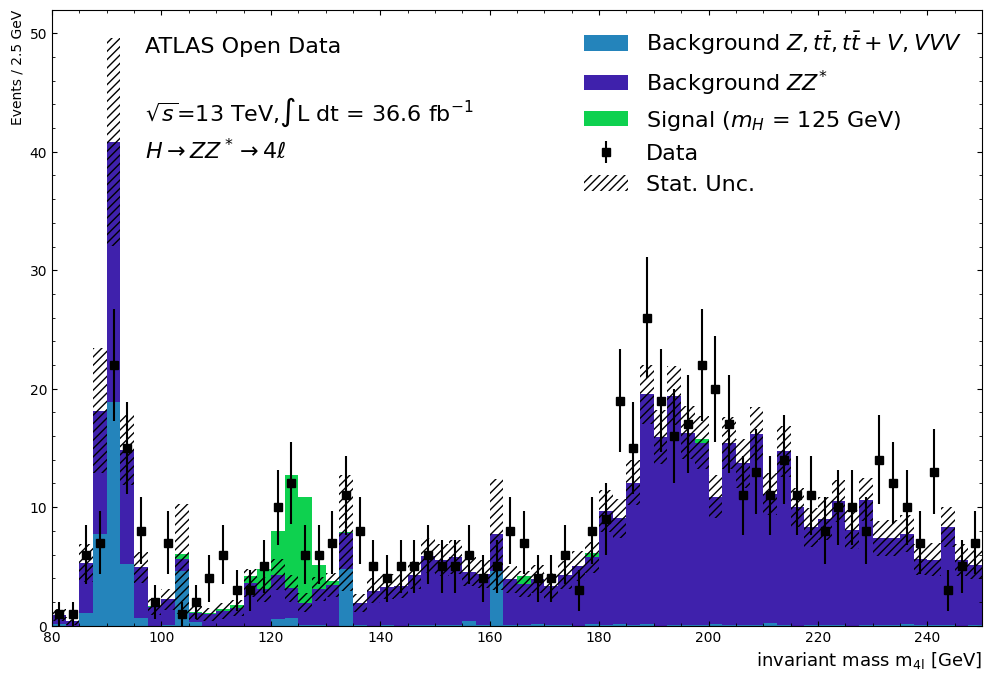

In [ ]:
fig, main_axes = plt.subplots(figsize=(12, 8))

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ks', # 'k' means black and 'o' is for circles
                    label='Data')

# plot the Monte Carlo bars
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels )

mc_x_tot = mc_heights[0][-1] # stacked background MC y-axis value

# calculate MC statistical uncertainty: sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges, weights=np.hstack(mc_weights)**2)[0])

# plot the signal bar
signal_heights = main_axes.hist(signal_x, bins=bin_edges, bottom=mc_x_tot,
                weights=signal_weights, color=signal_color,
                label=r'Signal ($m_H$ = 125 GeV)')

# plot the statistical uncertainty
main_axes.bar(bin_centres, # x
                2*mc_x_err, # heights
                alpha=0.5, # half transparency
                bottom=mc_x_tot-mc_x_err, color='none',
                hatch="////", width=step_size, label='Stat. Unc.' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*2.0 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# Add text 'ATLAS Open Data' on plot

plt.text(0.1, # x
            0.93, # y
            'ATLAS Open Data', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            fontsize=16 )
"""
plt.text(0.1, # x
            0.88, # y
            'for education', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            style='italic',
            fontsize=12 )
""" 

# Add energy and luminosity
lumi_used = str(lumi*fraction) # luminosity to write on the plot
plt.text(0.1, # x
            0.82, # y
            r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+' fb$^{-1}$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# Add a label for the analysis carried out
plt.text(0.1, # x
            0.76, # y
            r'$H \rightarrow ZZ^* \rightarrow 4\ell$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# draw the legend
my_legend = main_axes.legend( frameon=False, fontsize=16 )
plt.show()

In [ ]:
signal_tot = signal_heights[0] + mc_x_tot
N_sig = signal_tot[17:20].sum()
N_bg = mc_x_tot[17:20].sum()
signal_significance = N_sig/np.sqrt(N_bg + 0.25 * N_bg**2)
asimov_significance = np.sqrt(2*((N_sig+N_bg)*np.log(1+N_sig/N_bg)-N_sig))
N = N_sig + N_bg
relative_significance = np.sqrt(N)/N
print("relError=", relative_significance)
print("S/B=", signal_significance)
print("S/B=", asimov_significance)

relError= 0.16493888565287762
S/B= 5.735557797932015
S/B= 7.307382733329672


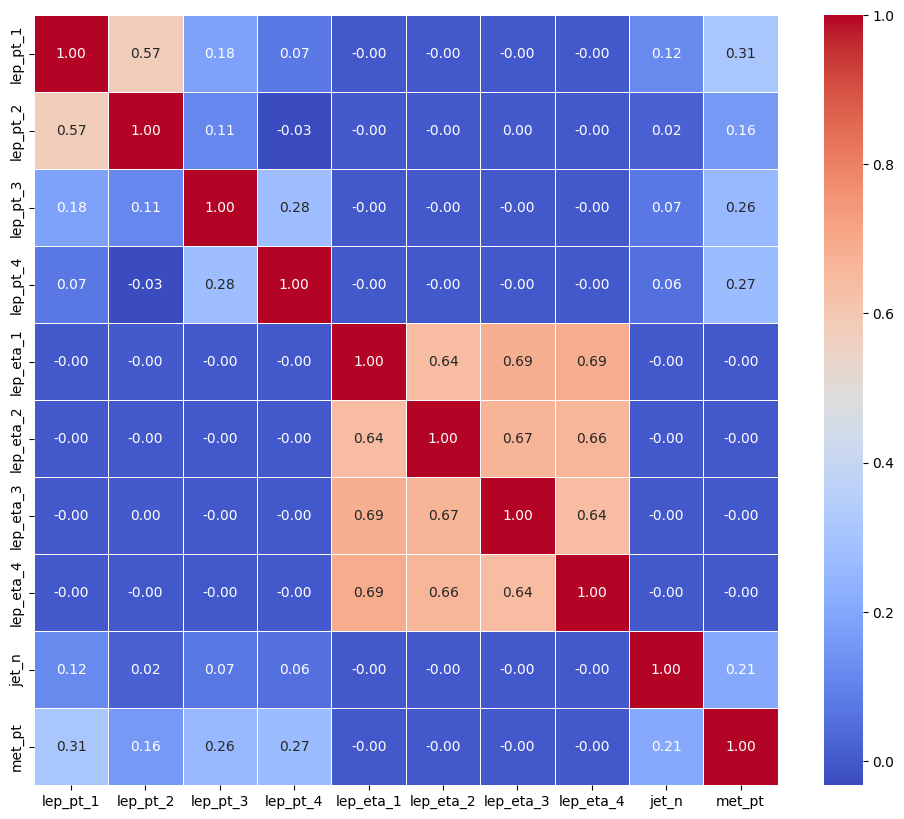

In [ ]:
import seaborn as sns
df_corr = pd.DataFrame(X, columns=BDT_inputs)
corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

In [ ]:
lumi = 36.6
fraction = 1.0

data = get_data_from_files()

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
in 1.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
in 2.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
in 2.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4

In [ ]:
data_for_NN = {} # define empty dictionary to hold dataframes that will be used to train the BDT
data = get_data_from_files() 
NN_inputs = ['lep_pt_1','lep_pt_2','lep_pt_3','lep_pt_4','lep_eta_1','lep_eta_2','lep_eta_3','lep_eta_4','jet_n', 'met_pt'] # list of features for BDT
for key in data: # loop over the different keys in the dictionary of dataframes
    data_for_NN[key] = data[key][NN_inputs]

all_MC = [] # define empty list that will contain all features for the MC
for key in data: 
    if key!='data': 
        all_MC.append(data_for_NN[key]) # append the MC dataframe to the list containing all MC features
X = np.concatenate(all_MC) # concatenate the list of MC dataframes into a single 2D array of features, called X

all_y = [] # define empty list that will contain labels whether an event in signal or background
for key in data: # loop over the different keys in the dictionary of dataframes
    if key!=r'Signal ($m_H$ = 125 GeV)' and key!='data': # only background MC should pass this
        all_y.append(np.zeros(len(data_for_NN[key]))) # background events are labelled with 0
all_y.append(np.ones(len(data_for_NN[r'Signal ($m_H$ = 125 GeV)']))) # signal events are labelled with 1
y = np.concatenate(all_y) 

from sklearn.model_selection import train_test_split

# make train and test sets
X_train,X_test, y_train,y_test = train_test_split(X, y, 
                                                  test_size=0.33, 
                                                  random_state=492 )

X_train = ak.to_dataframe(X_train)
y_train = ak.to_numpy(y_train)

X_test = ak.to_dataframe(X_test)
y_test = ak.to_numpy(y_test)

X = ak.to_dataframe(X)
y = ak.to_numpy(y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X = scaler.transform(X)

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
in 1.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
in 1.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
in 2.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
in 2.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4

In [ ]:
from sklearn.neural_network import MLPClassifier
hidden_layer_sizes = [200, 100] # 1 hidden layer
mlp = MLPClassifier(hidden_layer_sizes=(hidden_layer_sizes), # define parameters for our multi-layer-perceptron
                    max_iter=500 ) # max number of iterations
mlp.fit(X_train,y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[200, 100]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


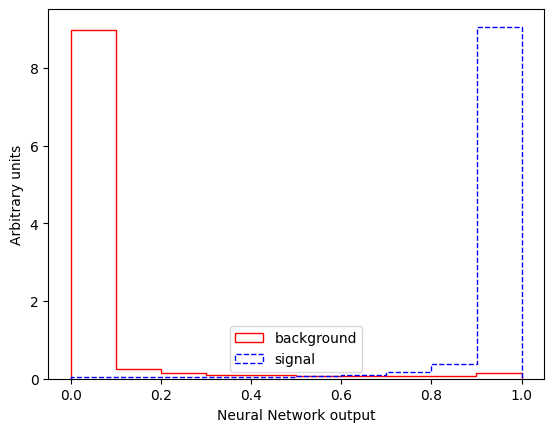

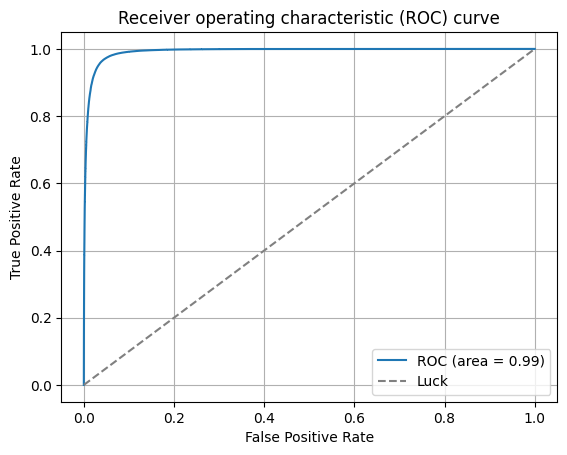

In [ ]:
signal_decisions = mlp.predict_proba(X[y>0.5])[:, 1] # get probabilities on signal
background_decisions = mlp.predict_proba(X[y<0.5])[:, 1] # get probabilities on background

plt.hist(background_decisions, color='red', label='background', 
         histtype='step', # lineplot that's unfilled
         density=True ) # normalize to form a probability density
plt.hist(signal_decisions, color='blue', label='signal', 
         histtype='step', # lineplot that's unfilled
         density=True, # normalize to form a probability density
         linestyle='--' ) # dashed line
plt.xlabel('Neural Network output') # add x-axis label
plt.ylabel('Arbitrary units') # add y-axis label
plt.legend() # add legend


# we then plot the ROC
plt.figure() # make new figure 

from sklearn.metrics import roc_curve, auc

decisions = mlp.predict_proba(X_test)[:, 1] # get probabilities on test set

# Compute ROC curve and area under the curve
fpr, tpr, _ = roc_curve(y_test, # actual
                        decisions ) # predicted

# Compute area under the curve for training set
roc_auc = auc(fpr, # false positive rate 
              tpr) # true positive rate

plt.plot(fpr, tpr, label='ROC (area = %0.2f)'%(roc_auc)) # plot test ROC curve
plt.plot([0, 1], # x from 0 to 1
         [0, 1], # y from 0 to 1
         '--', # dashed line
         color='grey', label='Luck')

plt.xlabel('False Positive Rate') # x-axis label
plt.ylabel('True Positive Rate') # y-axis label
plt.title('Receiver operating characteristic (ROC) curve') # title
plt.legend() # add legend
plt.grid() # add grid

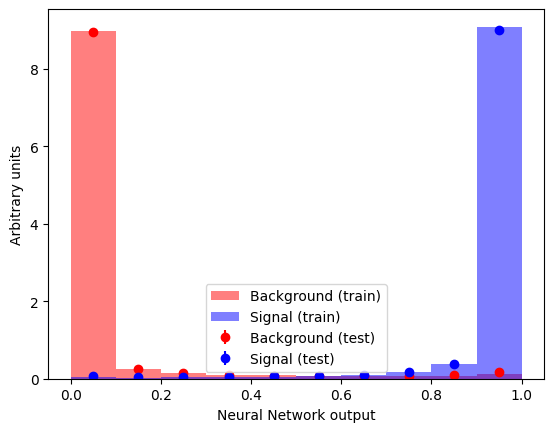

In [ ]:
def compare_train_test(clf, X_train, y_train, X_test, y_test):
    decisions = [] # list to hold decisions of classifier
    for X,y in ((X_train, y_train), (X_test, y_test)): # train and test
        d1 = clf.predict_proba(X[y<0.5])[:, 1] # background
        d2 = clf.predict_proba(X[y>0.5])[:, 1] # signal
        decisions += [d1, d2] # add to list of classifier decision
    
    highest_decision = max(np.max(d) for d in decisions) # get maximum score
    bin_edges = [] # list to hold bin edges
    bin_edge = -0.1 # start counter for bin_edges
    while bin_edge < highest_decision: # up to highest score
        bin_edge += 0.1 # increment
        bin_edges.append(bin_edge)
    
    plt.hist(decisions[0], # background in train set
             bins=bin_edges, # lower and upper range of the bins
             density=True, # area under the histogram will sum to 1
             histtype='stepfilled', # lineplot that's filled
             color='red', label='Background (train)', # Background (train)
            alpha=0.5 ) # half transparency
    plt.hist(decisions[1], # background in train set
             bins=bin_edges, # lower and upper range of the bins
             density=True, # area under the histogram will sum to 1
             histtype='stepfilled', # lineplot that's filled
             color='blue', label='Signal (train)', # Signal (train)
            alpha=0.5 ) # half transparency

    hist_background, bin_edges = np.histogram(decisions[2], # background test
                                              bins=bin_edges, # number of bins in function definition
                                              density=True ) # area under the histogram will sum to 1
    
    scale = len(decisions[2]) / sum(hist_background) # between raw and normalised
    err_background = np.sqrt(hist_background * scale) / scale # error on test background

    width = 0.1 # histogram bin width
    center = (bin_edges[:-1] + bin_edges[1:]) / 2 # bin centres
    
    plt.errorbar(x=center, y=hist_background, yerr=err_background, fmt='o', # circles
                 c='red', label='Background (test)' ) # Background (test)
    
    hist_signal, bin_edges = np.histogram(decisions[3], # siganl test
                                          bins=bin_edges, # number of bins in function definition
                                          density=True ) # area under the histogram will sum to 1
    scale = len(decisions[3]) / sum(hist_signal) # between raw and normalised
    err_signal = np.sqrt(hist_signal * scale) / scale # error on test background
    
    plt.errorbar(x=center, y=hist_signal, yerr=err_signal, fmt='o', # circles
                 c='blue', label='Signal (test)' ) # Signal (test)
    
    plt.xlabel("Neural Network output") # write x-axis label
    plt.ylabel("Arbitrary units") # write y-axis label
    plt.legend() # add legend
    
compare_train_test(mlp, X_train, y_train, X_test, y_test) # call compare_train_test

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:
in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:
in 1.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:
in 1.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:
in 2.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:
in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:
in 2.7s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4

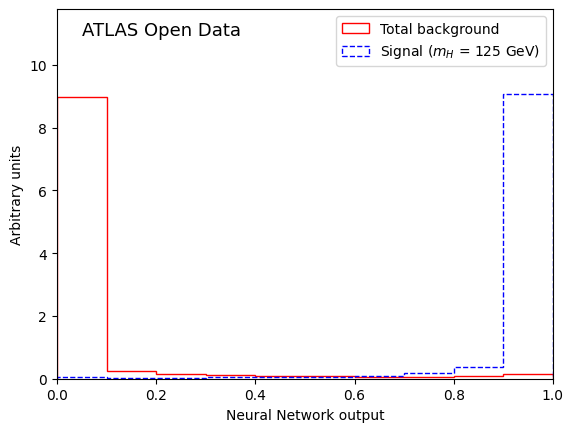

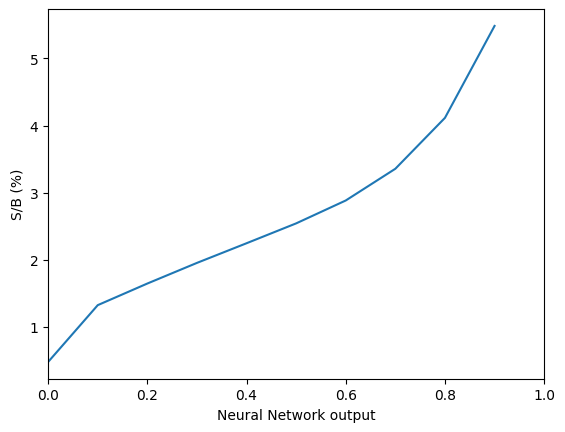

In [ ]:
data = get_data_from_files()
y_predicted = mlp.predict_proba(X)[:, 1]
cumulative_events = 0
for key in data: # loop over samples
    data[key]['NN_output'] = y_predicted[cumulative_events:cumulative_events+len(data[key])]
    cumulative_events += len(data[key])

NN_output = { # dictionary containing plotting parameters for the mllll histogram
    # change plotting parameters
    'bin_width':0.1, # width of each histogram bin
    'num_bins':10, # number of histogram bins
    'xrange_min':0, # minimum on x-axis
    'xlabel':'Neural Network output', # x-axis label
}

SoverB_hist_dict = {'NN_output':NN_output}
plot_SoverB(data)

In [ ]:
lumi = 36.6

# Controls the fraction of all events analysed
fraction = 1.0 # reduce this is if you want quicker runtime (implemented in the loop over the tree)

# Define empty dictionary to hold awkward arrays
all_data = {}

# Loop over samples
for s in samples:

    # Print which sample is being processed
    print('Processing '+s+' samples')

    # Define empty list to hold data
    frames = []

    # Loop over each file
    for val in samples[s]['list']:
        if s == 'data':
            prefix = "Data/" # Data prefix
        else: # MC prefix
            prefix = "MC/mc_"
        fileString = val.replace("simplecache::", "")

        # start the clock
        start = time.time()
        print("\t"+val+":")

        # Open file
        file_name = os.path.basename(fileString)
        local_path = os.path.join(r"C:\Users\Cucuruz\Downloads\H2ZZ", file_name)
        if not os.path.exists(local_path):
            with requests.get(fileString, stream=True) as r:
                r.raise_for_status()
                with open(local_path, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024*1024):
                        f.write(chunk)

        tree = uproot.open(local_path)['analysis']

        sample_data = []

        # Loop over data in the tree
        for data in tree.iterate(variables + weight_variables + ["sum_of_weights", "lep_n"],
                                 library="ak",
                                 entry_stop=tree.num_entries*fraction,#, # process up to numevents*fraction
                                 step_size = 10000000):

            # Number of events in this batch
            nIn = len(data)
            
            #data = data[data['lep_n'] == 4]
            data = data[cut_trig(data.trigE, data.trigM)]
            data = data[cut_trig_match(data.lep_isTrigMatched)]
            
            lep_type = data['lep_type']
            data = data[~cut_lep_type(lep_type)]
            lep_charge = data['lep_charge']
            data = data[~cut_lep_charge(lep_charge)]
            
            data = data[ID_iso_cut(data.lep_isLooseID,
                                   data.lep_isMediumID,
                                   data.lep_isLooseIso,
                                   data.lep_isLooseIso,
                                   data.lep_type)]
            
            lep_mass = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
                #data = data[(lep_mass > 115) & (lep_mass < 130)]

            data['lep_pt_1'] = data['lep_pt'][:,0]
            data['lep_pt_2'] = data['lep_pt'][:,1]
            data['lep_pt_3'] = data['lep_pt'][:,2]
            data['lep_pt_4'] = data['lep_pt'][:,3]
            data['lep_eta_1'] = data['lep_eta'][:,0]
            data['lep_eta_2'] = data['lep_eta'][:,1]
            data['lep_eta_3'] = data['lep_eta'][:,2]
            data['lep_eta_4'] = data['lep_eta'][:,3]

            """
            delta_phi = (data['lep_phi_1']-data['lep_phi_2'])
            delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
            data['iso_angle_1'] = np.sqrt((data['lep_eta_1']-data['lep_eta_2'])**2+delta_phi**2)
            delta_phi = (data['lep_phi_3']-data['lep_phi_4'])
            delta_phi = (delta_phi + np.pi) % (2 * np.pi) - np.pi
            data['iso_angle_2'] = np.sqrt((data['lep_eta_3']-data['lep_eta_4'])**2+delta_phi**2)
            """
                
            data['met_pt'] = np.sqrt(data['met_mpx']**2+data['met_mpy']**2)
            data['lep_mass'] = lep_mass
            
            X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
            X_batch_scaled = scaler.transform(X_batch)
            nn_probs = mlp.predict_proba(X_batch_scaled)[:, 1]
            data = data[nn_probs >= 0.9]

            # Invariant Mass
            data['mass'] = calc_mass(data['lep_pt'], data['lep_eta'], data['lep_phi'], data['lep_e'])

            # Store Monte Carlo weights in the data
            if 'data' not in s: # Only calculates weights if the data is MC
                data['totalWeight'] = calc_weight(weight_variables, data)
                # data['totalWeight'] = calc_weight(data)

            # Append data to the whole sample data list
            sample_data.append(data)

            if not 'data' in val:
                nOut = sum(data['totalWeight']) # sum of weights passing cuts in this batch
            else:
                nOut = len(data)

            elapsed = time.time() - start # time taken to process
            print("\t\t nIn: "+str(nIn)+",\t nOut: \t"+str(nOut)+"\t in "+str(round(elapsed,1))+"s") # events before and after

        frames.append(ak.concatenate(sample_data))

    all_data[s] = ak.concatenate(frames) # dictionary entry is concatenated awkward arrays

data_x,_ = np.histogram(ak.to_numpy(all_data['Data']['mass']),
                        bins=bin_edges ) # histogram the data
data_x_errors = np.sqrt( data_x ) # statistical error on the data

signal_x = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)']['mass']) # histogram the signal
signal_weights = ak.to_numpy(all_data[r'Signal ($m_H$ = 125 GeV)'].totalWeight) # get the weights of the signal events
signal_color = samples[r'Signal ($m_H$ = 125 GeV)']['color'] # get the colour for the signal bar

mc_x = [] # define list to hold the Monte Carlo histogram entries
mc_weights = [] # define list to hold the Monte Carlo weights
mc_colors = [] # define list to hold the colors of the Monte Carlo bars
mc_labels = [] # define list to hold the legend labels of the Monte Carlo bars

for s in samples: # loop over samples
    if s not in ['Data', r'Signal ($m_H$ = 125 GeV)']: # if not data nor signal
        mc_x.append( ak.to_numpy(all_data[s]['mass']) ) # append to the list of Monte Carlo histogram entries
        mc_weights.append( ak.to_numpy(all_data[s].totalWeight) ) # append to the list of Monte Carlo weights
        mc_colors.append( samples[s]['color'] ) # append to the list of Monte Carlo bar colors
        mc_labels.append( s ) # append to the list of Monte Carlo legend labels

Processing Data samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodD.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 3424,	 nOut: 	0	 in 0.5s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodE.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 25092,	 nOut: 	2	 in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodF.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 16234,	 nOut: 	2	 in 1.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodG.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 37101,	 nOut: 	6	 in 2.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodH.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 12152,	 nOut: 	1	 in 0.4s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data15_periodJ.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 67630,	 nOut: 	8	 in 2.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodA.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 29275,	 nOut: 	5	 in 2.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodB.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 72544,	 nOut: 	12	 in 1.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodC.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 91124,	 nOut: 	17	 in 1.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodD.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 174618,	 nOut: 	42	 in 2.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodE.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 54896,	 nOut: 	9	 in 0.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodF.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 118615,	 nOut: 	23	 in 1.6s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodG.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 134798,	 nOut: 	23	 in 1.9s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodI.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 205285,	 nOut: 	42	 in 2.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodK.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 84130,	 nOut: 	9	 in 1.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_data16_periodL.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 235693,	 nOut: 	38	 in 2.9s
Processing Background $Z,t\bar{t},t\bar{t}+V,VVV$ samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410470.PhPy8EG_A14_ttbar_hdamp258p75_nonallhad.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 13763,	 nOut: 	2	 in 8.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410155.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttW.exactly4lep.root:
		 nIn: 133,	 nOut: 	0	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410218.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttee.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 2735,	 nOut: 	42	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_410219.aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttmumu.exactly4lep.root:
		 nIn: 4400,	 nOut: 	105	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_412043.aMcAtNloPythia8EvtGen_A14NNPDF31_SM4topsNLO.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 1127,	 nOut: 	4	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364243.Sherpa_222_NNPDF30NNLO_WWZ_4l2v_EW6.exactly4lep.root:
		 nIn: 7664,	 nOut: 	212	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364242.Sherpa_222_NNPDF30NNLO_WWW_3l3v_EW6.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 470,	 nOut: 	2	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364246.Sherpa_222_NNPDF30NNLO_WZZ_3l3v_EW6.exactly4lep.root:
		 nIn: 220,	 nOut: 	0	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_364248.Sherpa_222_NNPDF30NNLO_ZZZ_4l2v_EW6.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 2006,	 nOut: 	45	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700320.Sh_2211_Zee_maxHTpTV2_BFilter.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 9901,	 nOut: 	2	 in 0.7s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700321.Sh_2211_Zee_maxHTpTV2_CFilterBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 25201,	 nOut: 	1	 in 3.1s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700322.Sh_2211_Zee_maxHTpTV2_CVetoBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 45787,	 nOut: 	6	 in 1.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 9602,	 nOut: 	7	 in 0.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700324.Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 25329,	 nOut: 	1	 in 2.3s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700325.Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 47476,	 nOut: 	1	 in 2.5s
Processing Background $ZZ^{*}$ samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_700600.Sh_2212_llll.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 11260,	 nOut: 	1150	 in 0.2s
Processing Signal ($m_H$ = 125 GeV) samples
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_345060.PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_ZZ4l.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 419943,	 nOut: 	286667	 in 3.0s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346228.PowhegPy8EG_NNPDF30_AZNLOCTEQ6L1_VBFH125_ZZ4lep_notau.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


		 nIn: 86084,	 nOut: 	56506	 in 0.8s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346310.PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Zincl_H_incl_MINLO.exactly4lep.root:
		 nIn: 44,	 nOut: 	10	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346311.PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Wincl_H_incl_MINLO.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 4,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346312.PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Wincl_H_incl_MINLO.exactly4lep.root:
		 nIn: 4,	 nOut: 	1	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346340.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_allhad.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 7146,	 nOut: 	3029	 in 0.5s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346341.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_semilep.exactly4lep.root:
		 nIn: 10072,	 nOut: 	1713	 in 0.2s
	simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_exactly4lep_mc_346342.PowhegPy8EG_A14NNPDF23_NNPDF30ME_ttH125_ZZ4l_dilep.exactly4lep.root:


C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_batch = np.column_stack([np.array(data[name]) for name in NN_inputs])
C:\Users\Cucuruz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Cucuruz\AppData\Local\Temp\ipykernel_6288\442972851.py:92: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the mi

		 nIn: 9332,	 nOut: 	1049	 in 0.2s


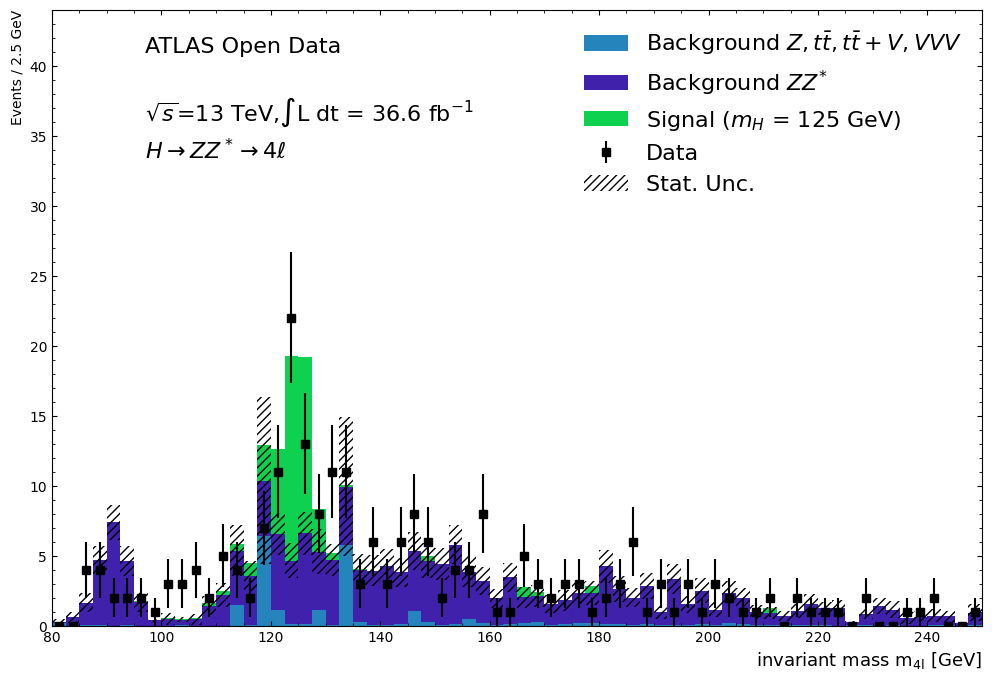

relError= 0.12572997547655648
S/B= 5.092882771994978
S/B= 8.75354818127233


In [ ]:
fig, main_axes = plt.subplots(figsize=(12, 8))

# plot the data points
main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                    fmt='ks', # 'k' means black and 'o' is for circles
                    label='Data')

# plot the Monte Carlo bars
mc_heights = main_axes.hist(mc_x, bins=bin_edges,
                            weights=mc_weights, stacked=True,
                            color=mc_colors, label=mc_labels )

mc_x_tot = mc_heights[0][-1] # stacked background MC y-axis value

# calculate MC statistical uncertainty: sqrt(sum w^2)
mc_x_err = np.sqrt(np.histogram(np.hstack(mc_x), bins=bin_edges, weights=np.hstack(mc_weights)**2)[0])

# plot the signal bar
signal_heights = main_axes.hist(signal_x, bins=bin_edges, bottom=mc_x_tot,
                weights=signal_weights, color=signal_color,
                label=r'Signal ($m_H$ = 125 GeV)')

# plot the statistical uncertainty
main_axes.bar(bin_centres, # x
                2*mc_x_err, # heights
                alpha=0.5, # half transparency
                bottom=mc_x_tot-mc_x_err, color='none',
                hatch="////", width=step_size, label='Stat. Unc.' )

# set the x-limit of the main axes
main_axes.set_xlim( left=xmin, right=xmax )

# separation of x axis minor ticks
main_axes.xaxis.set_minor_locator( AutoMinorLocator() )

# set the axis tick parameters for the main axes
main_axes.tick_params(which='both', # ticks on both x and y axes
                        direction='in', # Put ticks inside and outside the axes
                        top=True, # draw ticks on the top axis
                        right=True ) # draw ticks on right axis

# x-axis label
main_axes.set_xlabel(r'invariant mass $\mathrm{m_{4l}}$ [GeV]',
                    fontsize=13, x=1, horizontalalignment='right' )

# write y-axis label for main axes
main_axes.set_ylabel('Events / '+str(step_size)+' GeV',
                        y=1, horizontalalignment='right')

# set y-axis limits for main axes
main_axes.set_ylim( bottom=0, top=np.amax(data_x)*2.0 )

# add minor ticks on y-axis for main axes
main_axes.yaxis.set_minor_locator( AutoMinorLocator() )

# Add text 'ATLAS Open Data' on plot

plt.text(0.1, # x
            0.93, # y
            'ATLAS Open Data', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            fontsize=16 )
"""
plt.text(0.1, # x
            0.88, # y
            'for education', # text
            transform=main_axes.transAxes, # coordinate system used is that of main_axes
            style='italic',
            fontsize=12 )
""" 

# Add energy and luminosity
lumi_used = str(lumi*fraction) # luminosity to write on the plot
plt.text(0.1, # x
            0.82, # y
            r'$\sqrt{s}$=13 TeV,$\int$L dt = '+lumi_used+' fb$^{-1}$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# Add a label for the analysis carried out
plt.text(0.1, # x
            0.76, # y
            r'$H \rightarrow ZZ^* \rightarrow 4\ell$', # text
            transform=main_axes.transAxes,fontsize=16 ) # coordinate system used is that of main_axes

# draw the legend
my_legend = main_axes.legend( frameon=False, fontsize=16 )
plt.show()

signal_tot = signal_heights[0] + mc_x_tot
N_sig = signal_tot[17:20].sum()
N_bg = mc_x_tot[17:20].sum()
signal_significance = N_sig/np.sqrt(N_bg + 0.25 * N_bg**2)
asimov_significance = np.sqrt(2*((N_sig+N_bg)*np.log(1+N_sig/N_bg)-N_sig))
N = N_sig + N_bg
relative_significance = np.sqrt(N)/N
print("relError=", relative_significance)
print("S/B=", signal_significance)
print("S/B=", asimov_significance)

In [ ]:
signal_tot = signal_heights[0] + mc_x_tot
N_sig = signal_tot[17:20].sum()
N_bg = mc_x_tot[17:20].sum()
signal_significance = N_sig/np.sqrt(N_bg + 0.25 * N_bg**2)
asimov_significance = np.sqrt(2*((N_sig+N_bg)*np.log(1+N_sig/N_bg)-N_sig))
N = N_sig + N_bg
relative_significance = np.sqrt(N)/N
print("relError=", relative_significance)
print("S/B=", signal_significance)
print("S/B=", asimov_significance)


relError= 0.12572997547655648
S/B= 5.092882771994978
S/B= 8.75354818127233
